Databricks 

https://dbc-0b69ef93-5247.cloud.databricks.com/editor/notebooks/4248052592342662?o=7474657872577658

## Scaling with Pandas APIs

# Scaling Data with the Pandas API on Spark

### Formerly Koalas — the familiar pandas API, at Spark scale

**Purpose:** pandas is beloved but single-machine; Spark is distributed but a different API. The Pandas API on Spark bridges them — run your existing pandas code across a cluster by changing a single import.

---

| SINGLE MACHINE <br> **Pandas** | DISTRIBUTED <br> **Apache Spark** |
| :--- | :--- |
| Popular, familiar and very performant on small data, with deep NumPy / Matplotlib / scikit-learn integration. | A scalable, fast distributed engine supporting many data sources, workloads and languages. |

---

**Pandas API on Spark fills the gaps** — when your data gets big, run existing pandas code on Spark:
* Avoid learning a new framework and confusing pandas vs. Spark APIs
* Be more productive; maintain a single codebase
* Avoid time-consuming rewrites & testing

---

### ONE-LINE CHANGE

In [0]:
# Criar um ficheiro data.csv de exemplo com dados de vendas
sales_data = """transaction_id,customer_id,product_category,quantity,unit_price,total_amount,store_region
1001,CUS_8492,Electronics,1,1200.00,1200.00,North
1002,CUS_3104,Clothing,3,45.50,136.50,South
1003,CUS_5291,Home & Kitchen,2,89.90,179.80,East
1004,CUS_1102,Electronics,2,350.00,700.00,West
1005,CUS_9401,Clothing,1,120.00,120.00,North
"""
path='/Workspace/Users/fabieneaulas@gmail.com/ML_spark/'
# Guardar o ficheiro no diretório de trabalho do Databricks
file_path = f"{path}/data.csv"
#dbutils.fs.put(file_path, sales_data, overwrite=True)
# Change one import - the rest of your pandas code stays the same

In [0]:
dbutils.fs.put(file_path, sales_data, overwrite=True)

Wrote 325 bytes.


True

In [0]:


# Leitura com a Pandas API on Spark
import pyspark.pandas as ps # was: import pandas as pd

pdf = ps.read_csv(file_path)

# Exibe os dados e agrupa o total de vendas por categoria de produto
display(pdf.groupby("product_category")["total_amount"].sum())

/databricks/python/lib/python3.12/site-packages/pyspark/pandas/utils.py:1070: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


product_category
Home & Kitchen     179.8
Electronics       1900.0
Clothing           256.5
Name: total_amount, dtype: float64

In [0]:
pdf.tail()

,transaction_id,customer_id,product_category,quantity,unit_price,total_amount,store_region
0,1001,CUS_8492,Electronics,1,1200.0,1200.0,North
1,1002,CUS_3104,Clothing,3,45.5,136.5,South
2,1003,CUS_5291,Home & Kitchen,2,89.9,179.8,East
3,1004,CUS_1102,Electronics,2,350.0,700.0,West
4,1005,CUS_9401,Clothing,1,120.0,120.0,North


## Same idea, different semantics

**Purpose:** the two DataFrames behave differently — pandas is mutable and eager, PySpark is immutable and lazy. The Pandas API on Spark gives pandas syntax with Spark's execution model underneath.

| Feature | pandas DataFrame | PySpark DataFrame |
| :--- | :--- | :--- |
| **Column** | `df['col']` | `df['col']` |
| **Mutability** | Mutable | Immutable |
| **Execution** | Eager | Lazy |
| **Add a column** | `df['c'] = df['a'] + df['b']` | `df = df.withColumn('c', df['a'] + df['b'])` |
| **Rename columns** | `df.columns = ['a', 'b']` | `df.select(df['c1'].alias('a'), ...) ` ou `df.toDF('a', 'b')` |
| **Value count** | `df['col'].value_counts()` | `df.groupBy('col').count().orderBy('count', ascending=False)` |

---

### THE SAME OPERATION, THREE WAYS

In [0]:
# 1. Pandas (Single-node)
import pandas as pd
#pandas_df['C'] = pandas_df['A'] + pandas_df['B']

# 2. Apache Spark (PySpark DataFrame - Distribuído Nativo)
from pyspark.sql.functions import col
#spark_df = spark_df.withColumn('C', spark_df['A'] + spark_df['B'])

# 3. Pandas API on Spark (Sintaxe Pandas com Execução Distribuída Spark)
import pyspark.pandas as ps
#ps_df['C'] = ps_df['A'] + ps_df['B']

In [0]:
# Dados de exemplo de vendas
sales_data = {
    'A': [100.0, 45.5, 89.9],  # ex: Preço unitário
    'B': [200.0, 50.0, 10.1]   # ex: Taxa / Desconto
}

# 1. Usando Pandas nativo
import pandas as pd
pandas_df = pd.DataFrame(sales_data)
pandas_df['C'] = pandas_df['A'] + pandas_df['B']
display(pandas_df)

# 2. Usando PySpark
spark_df = spark.createDataFrame(pandas_df[['A', 'B']])
from pyspark.sql.functions import col
spark_df = spark_df.withColumn('C', spark_df['A'] + spark_df['B'])
display(spark_df)

# 3. Usando Pandas API on Spark (pyspark.pandas)
import pyspark.pandas as ps
ps_df = ps.DataFrame(sales_data)
ps_df['C'] = ps_df['A'] + ps_df['B']

# Exibir os resultados
display(ps_df)

A,B,C
100.0,200.0,300.0
45.5,50.0,95.5
89.9,10.1,100.0


A,B,C
100.0,200.0,300.0
45.5,50.0,95.5
89.9,10.1,100.0


/databricks/python/lib/python3.12/site-packages/pyspark/pandas/utils.py:1070: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


A,B,C
100.0,200.0,300.0
45.5,50.0,95.5
89.9,10.1,100.0


# CONVERT & PLOT

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import pyspark.sql.functions as F

# Load a Spark DataFrame from Unity Catalog
#sdf = spark.table("catalog.schema.table_name")

# Convert to pandas for Matplotlib (Spark can't plot directly)
#pdf = sdf.toPandas()
#pdf.plot(kind="bar", x="Name", y="Salary"); plt.show()

# Distributed group-by stays on Spark
#result = sdf.groupBy("Name").agg(F.avg("Salary").alias("AvgSal"))

# Convert a pandas DataFrame back to Spark
#sdf_converted = spark.createDataFrame(pdf)

# INTEGRATE WITH SQL

In [0]:
import pyspark.pandas as ps
#psdf = ps.read_table("catalog.schema.table_name")

# Method 1 - direct SQL with ps.sql()
#ps.sql("SELECT Name, Salary FROM {psdf} WHERE Salary > 6000").show()

# Method 2 - register a temp view, then Spark SQL
#psdf.spark.cache().createOrReplaceTempView("employees")
#spark.sql("SELECT Name, Salary FROM employees WHERE Salary > 6000").show()

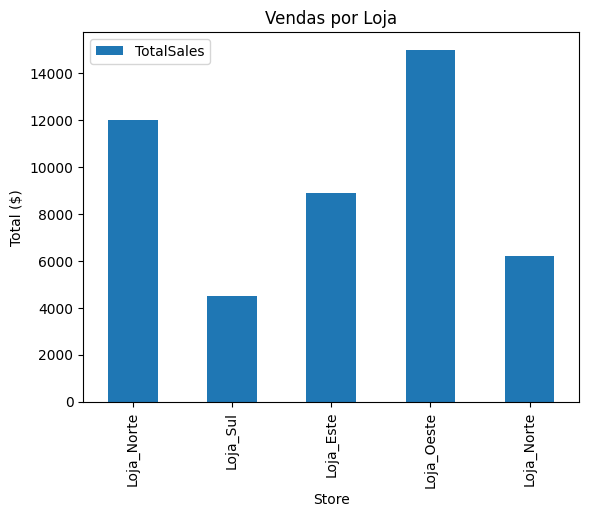

In [0]:
import pyspark.pandas as ps
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

# 1. Criar dados de vendas
sales_data = [
    ("Loja_Norte", "Eletrónicos", 12000.0),
    ("Loja_Sul", "Roupa", 4500.0),
    ("Loja_Este", "Casa", 8900.0),
    ("Loja_Oeste", "Eletrónicos", 15000.0),
    ("Loja_Norte", "Roupa", 6200.0)
]
columns = ["Store", "Category", "TotalSales"]

# Carregar como Spark DataFrame
sdf = spark.createDataFrame(sales_data, schema=columns)

# Conversão para Pandas para gerar gráfico de barras com Matplotlib
pdf = sdf.toPandas()
pdf.plot(kind="bar", x="Store", y="TotalSales", title="Vendas por Loja")
plt.ylabel("Total ($)")
plt.show()



In [0]:
# Agrupamento distribuído no Spark
result = sdf.groupBy("Category").agg(F.sum("TotalSales").alias("CategorySales"))
display(result)

Category,CategorySales
Eletrónicos,27000.0
Roupa,10700.0
Casa,8900.0


In [0]:


# Consulta SQL direta via Pandas API on Spark (ps.sql)
psdf = ps.DataFrame(sdf)
high_sales = ps.sql("SELECT Store, Category, TotalSales FROM {psdf} WHERE TotalSales > 6000", psdf=psdf)
display(high_sales)

/databricks/python/lib/python3.12/site-packages/pyspark/pandas/utils.py:1070: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


Store,Category,TotalSales
Loja_Norte,Eletrónicos,12000.0
Loja_Este,Casa,8900.0
Loja_Oeste,Eletrónicos,15000.0
Loja_Norte,Roupa,6200.0
